Loading sampler artifacts from: /workspaces/swe-pinn/data/experiment_6/domain_artifacts.npz
Loading sampler artifacts from: /workspaces/swe-pinn/data/experiment_6/domain_artifacts.npz
  - Registered boundary 'wall': 21 segments
  - Registered boundary 'upstream': 5 segments
  - Registered boundary 'building': 3252 segments
Sampling 100000 interior points...
Found boundary types: ['wall', 'upstream', 'building']
  - Sampling 'wall' (20000 points)...
  - Sampling 'upstream' (20000 points)...
  - Sampling 'building' (20000 points)...
Generating plot...
Domain Bounds: X[560619.6, 561358.9], Y[99683.6, 100382.9]
Plot saved to check_mesh_density.png


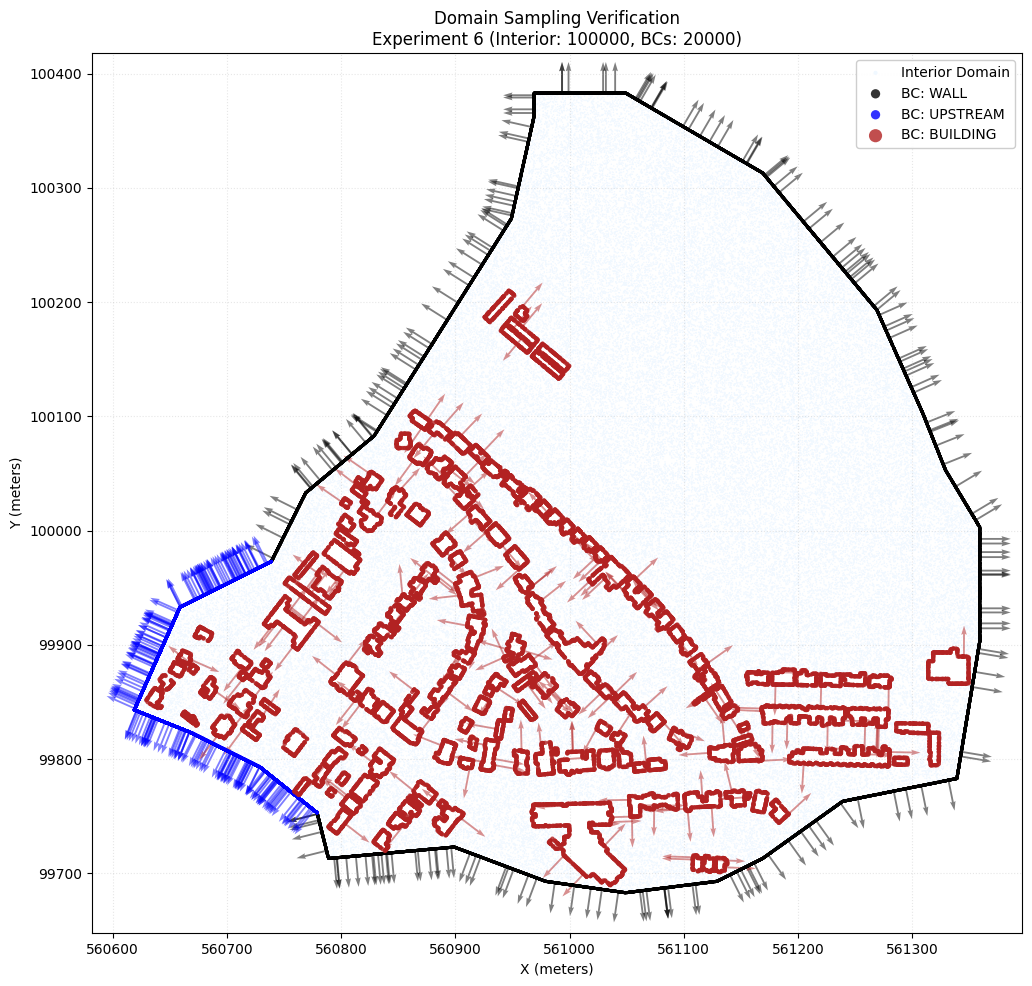

In [10]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

# --- Setup Paths ---
# Add project root to path so we can import src
try:
    # Assuming this script is in scripts/ or similar relative to root
    project_root = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
except NameError:
    # Fallback for interactive environments (notebooks/REPL)
    project_root = os.getcwd()

if project_root not in sys.path:
    sys.path.insert(0, project_root)

# --- Configuration ---
# Set JAX to use CPU for plotting to avoid OOM on small GPUs/rendering
jax.config.update("jax_platform_name", "cpu")

import src.config
src.config.DTYPE = jnp.float32

from src.data import IrregularDomainSampler

# Path to your artifacts (ensure this matches where you ran the preprocess script)
ARTIFACTS_PATH = os.path.join(project_root, "/workspaces/swe-pinn/data/experiment_6/domain_artifacts.npz")

def main():
    if not os.path.exists(ARTIFACTS_PATH):
        print(f"Error: Artifacts not found at {ARTIFACTS_PATH}")
        print("Please run scripts/preprocess_irregular.py first.")
        return

    print(f"Loading sampler artifacts from: {ARTIFACTS_PATH}")
    
    # Initialize Sampler
    # The updated IrregularDomainSampler automatically detects keys like 'bc_building', 'bc_upstream'
    try:
        sampler = IrregularDomainSampler(ARTIFACTS_PATH)
    except Exception as e:
        print(f"Failed to initialize sampler: {e}")
        return
    
    # Setup JAX keys
    key = jax.random.PRNGKey(42)
    k_int, k_bnd = jax.random.split(key)

    # --- Sampling Configuration ---
    # High density numbers for "good density" visualization
    N_INTERIOR = 100_000
    N_BOUNDARY = 20_000
    
    # 1. Sample Interior
    print(f"Sampling {N_INTERIOR} interior points...")
    # t_bounds are required by the API but irrelevant for spatial 2D plotting
    interior_pts = sampler.sample_interior(k_int, n_points=N_INTERIOR, t_bounds=(0, 1))
    
    # 2. Sample All Boundaries
    bnd_samples = {}
    available_boundaries = list(sampler.boundaries.keys())
    print(f"Found boundary types: {available_boundaries}")
    
    for label in available_boundaries:
        k_bnd, subkey = jax.random.split(k_bnd)
        print(f"  - Sampling '{label}' ({N_BOUNDARY} points)...")
        # Determine specific density based on label if needed, otherwise uniform
        n_b = N_BOUNDARY
        
        # Sample
        pts = sampler.sample_boundary(subkey, n_points=n_b, t_bounds=(0, 1), boundary_type=label)
        bnd_samples[label] = pts

    # --- Plotting ---
    print("Generating plot...")
    fig, ax = plt.subplots(figsize=(12, 12))
    
    # Plot Interior
    # Use s=0.5 or s=1 with low alpha to visualize density gradients if they exist
    ax.scatter(interior_pts[:, 0], interior_pts[:, 1], 
               s=1, c='aliceblue', edgecolors='none', alpha=1.0, 
               label='Interior Domain', rasterized=True)
    
    # Plot Boundaries with distinct colors
    # Define a color map for common types
    color_map = {
        'wall': 'black',
        'building': 'firebrick',
        'upstream': 'blue',
        'downstream': 'green',
        'inflow': 'blue',
        'outflow': 'green'
    }
    fallback_colors = ['purple', 'orange', 'cyan', 'magenta']
    
    for i, (label, pts) in enumerate(bnd_samples.items()):
        if pts.shape[0] == 0:
            continue
            
        color = color_map.get(label, fallback_colors[i % len(fallback_colors)])
        marker = '.'
        
        # Make buildings stand out
        size = 10 if label == 'building' else 5
        zorder = 10 if label == 'building' else 5
        
        ax.scatter(pts[:, 0], pts[:, 1], 
                   s=size, c=color, label=f"BC: {label.upper()}", 
                   alpha=0.8, edgecolors='none', zorder=zorder)

        # Plot normal vectors for a subset of points (to verify orientation)
        # pts has shape (N, 5) -> [x, y, t, nx, ny]
        if pts.shape[1] >= 5:
            step = max(1, len(pts) // 200) # Plot ~200 arrows per boundary
            subset = pts[::step]
            ax.quiver(subset[:, 0], subset[:, 1], subset[:, 3], subset[:, 4],
                      color=color, scale=30, width=0.002, alpha=0.5)

    ax.set_aspect('equal')
    ax.set_title(f"Domain Sampling Verification\nExperiment 6 (Interior: {N_INTERIOR}, BCs: {N_BOUNDARY})")
    ax.set_xlabel("X (meters)")
    ax.set_ylabel("Y (meters)")
    ax.legend(loc='upper right', framealpha=0.95, markerscale=3)
    ax.grid(True, linestyle=':', alpha=0.3)
    
    # Add coordinates info
    x_min, x_max = interior_pts[:, 0].min(), interior_pts[:, 0].max()
    y_min, y_max = interior_pts[:, 1].min(), interior_pts[:, 1].max()
    print(f"Domain Bounds: X[{x_min:.1f}, {x_max:.1f}], Y[{y_min:.1f}, {y_max:.1f}]")
    
    out_file = "check_mesh_density.png"
    plt.savefig(out_file, dpi=300, bbox_inches='tight')
    print(f"Plot saved to {out_file}")
    plt.show()

if __name__ == "__main__":
    main()

Loading sampler artifacts from: /workspaces/swe-pinn/data/experiment_6/domain_artifacts.npz
Loading sampler artifacts from: /workspaces/swe-pinn/data/experiment_6/domain_artifacts.npz
  - Registered boundary 'wall': 21 segments
  - Registered boundary 'upstream': 5 segments
  - Registered boundary 'building': 3252 segments
Sampling 50,000 PDE points...
Loading buildings from /workspaces/swe-pinn/data/experiment_6/Buildings_cleaned.shp...
Generating verification plot...
Number of PDE samples generated: 50000
Sample X range: 560619.88 to 561359.00
Sample Y range: 99683.44 to 100382.80
Verification plot saved to check_pde_voids_fixed.png


/tmp/ipykernel_10610/4121183476.py:75: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="upper right")


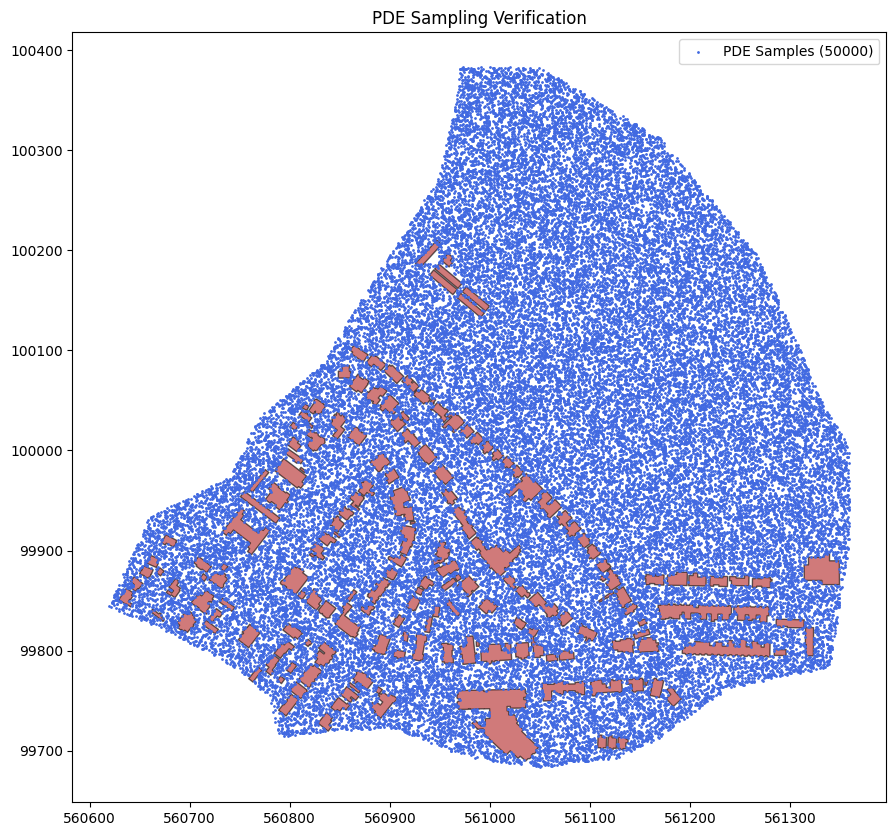

In [15]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import jax
import jax.numpy as jnp
from shapely.geometry import Point

# --- Setup Paths ---
try:
    project_root = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
except NameError:
    project_root = os.getcwd()

if project_root not in sys.path:
    sys.path.insert(0, project_root)

import src.config
src.config.DTYPE = jnp.float32
from src.data import IrregularDomainSampler

# --- CORRECTED PATHS ---
# Using the absolute paths you provided directly
ARTIFACTS_PATH = "/workspaces/swe-pinn/data/experiment_6/domain_artifacts.npz"
BUILDINGS_PATH = "/workspaces/swe-pinn/data/experiment_6/Buildings_cleaned.shp"

def main():
    # 1. Initialize Sampler
    if not os.path.exists(ARTIFACTS_PATH):
        print(f"Error: Artifacts not found at {ARTIFACTS_PATH}")
        print("Did you run 'scripts/preprocess_irregular.py' with the --buildings flag yet?")
        return
    
    print(f"Loading sampler artifacts from: {ARTIFACTS_PATH}")
    sampler = IrregularDomainSampler(ARTIFACTS_PATH)
    
    # 2. Sample PDE Points (Interior)
    print("Sampling 50,000 PDE points...")
    key = jax.random.PRNGKey(0)
    # Sample interior points (time is irrelevant for this spatial check)
    pde_samples = sampler.sample_interior(key, n_points=50000, t_bounds=(0, 1))
    pde_xy = pde_samples[:, :2] # Extract (x, y)
    
    # 3. Load Buildings for Verification
    if not os.path.exists(BUILDINGS_PATH):
        print(f"Error: Buildings file not found at {BUILDINGS_PATH}")
        return

    print(f"Loading buildings from {BUILDINGS_PATH}...")
    try:
        buildings_gdf = gpd.read_file(BUILDINGS_PATH)
    except Exception as e:
        print(f"Could not load buildings for verification: {e}")
        return

# 4. Plotting Verification
    print("Generating verification plot...")
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # A. Plot Buildings (Red Voids)
    buildings_gdf.plot(ax=ax, color='firebrick', alpha=0.6, edgecolor='black', label='Buildings (Obstacles)')
    
    # B. Plot PDE Samples (Dark Blue)
    # Changed from 'aliceblue' to 'blue' and s=0.5 to s=1.0 for visibility
    pts_np = np.array(pde_xy)
    if len(pts_np) > 0:
        ax.scatter(pts_np[:, 0], pts_np[:, 1], s=1.0, c='royalblue', label=f'PDE Samples ({len(pts_np)})')
    else:
        print("WARNING: PDE Sample array is empty!")

    # C. Formatting
    ax.set_title("PDE Sampling Verification")
    ax.set_aspect('equal')
    ax.legend(loc="upper right")
    
    # Print stats to terminal to confirm data exists
    print(f"Number of PDE samples generated: {len(pts_np)}")
    if len(pts_np) > 0:
        print(f"Sample X range: {pts_np[:,0].min():.2f} to {pts_np[:,0].max():.2f}")
        print(f"Sample Y range: {pts_np[:,1].min():.2f} to {pts_np[:,1].max():.2f}")
    
    output_file = "check_pde_voids_fixed.png"
    plt.savefig(output_file, dpi=150)
    print(f"Verification plot saved to {output_file}")
    plt.show()

if __name__ == "__main__":
    main()

Project Root: /workspaces/swe-pinn
Data Path: /workspaces/swe-pinn/data/experiment_6
Artifacts Path: /workspaces/swe-pinn/data/experiment_6/domain_artifacts.npz
Loading domain geometry...
Loading sampler artifacts from: /workspaces/swe-pinn/data/experiment_6/domain_artifacts.npz
  - Registered boundary 'wall': 21 segments
  - Registered boundary 'upstream': 5 segments
  - Registered boundary 'building': 3252 segments
Loading weights from: /workspaces/swe-pinn/models/2026-02-10_17-41_experiment_6/2026-02-10_17-41_experiment_6_params.pkl
Generating plot for t = 0.0s...


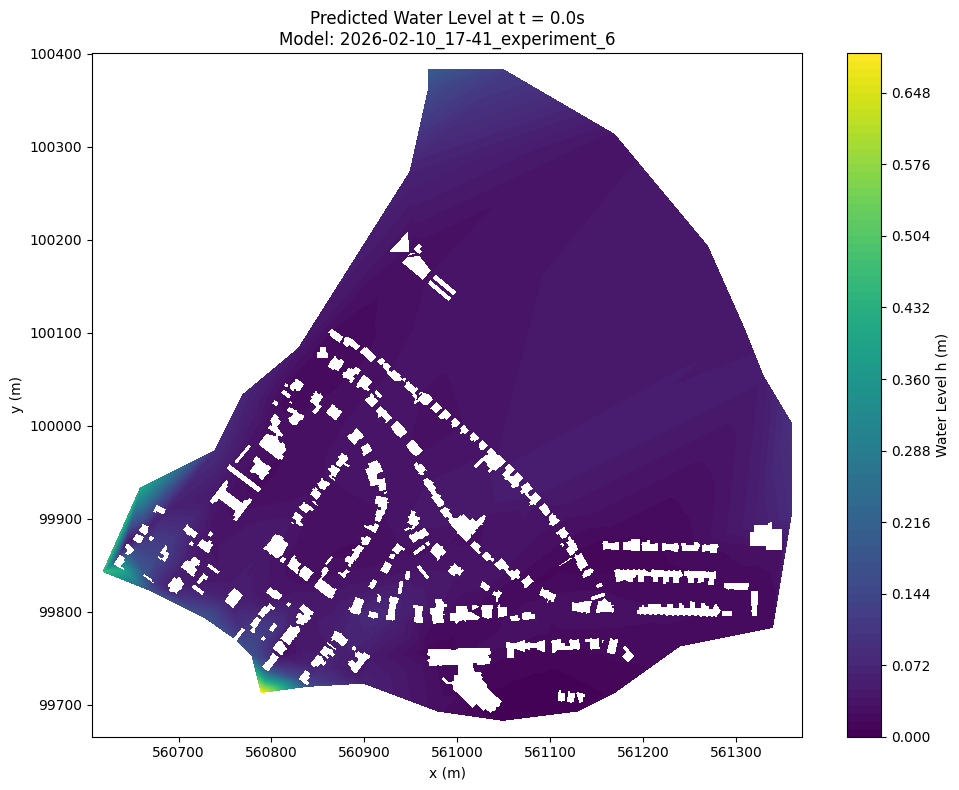

Generating plot for t = 3600.0s...


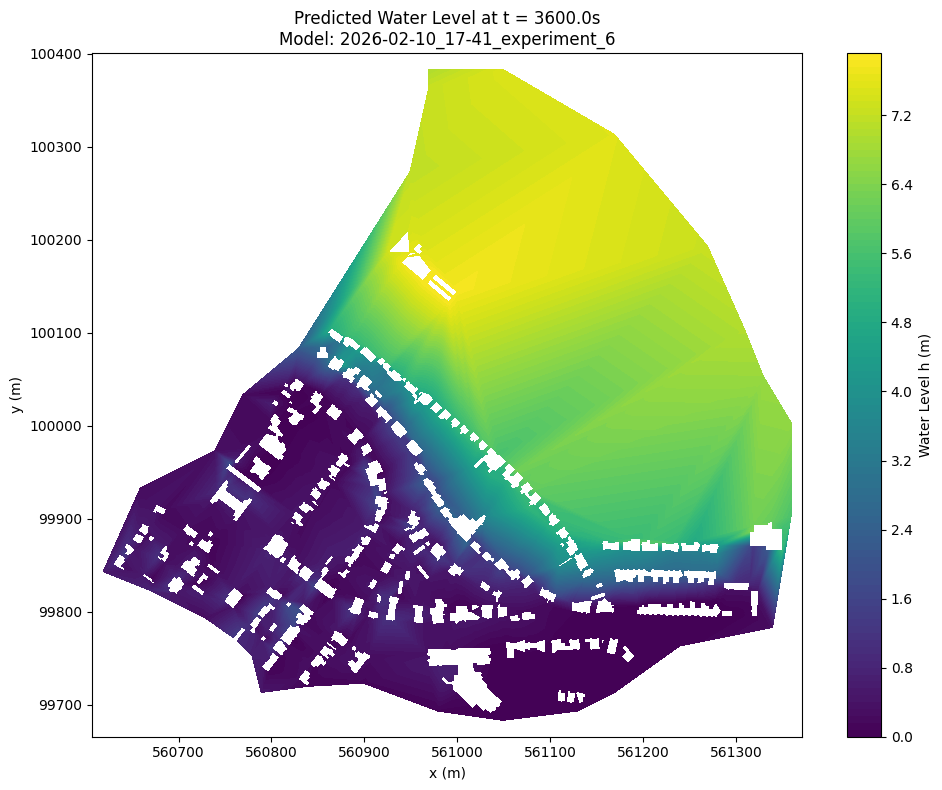

Generating plot for t = 21600.0s...


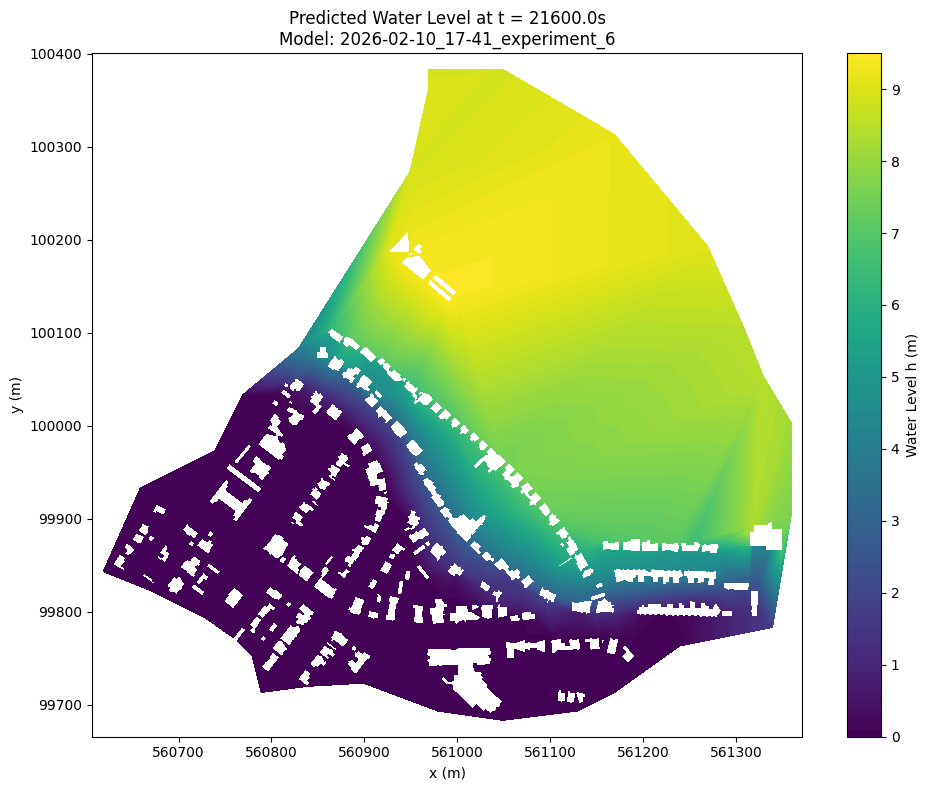

Generating plot for t = 10800.0s...


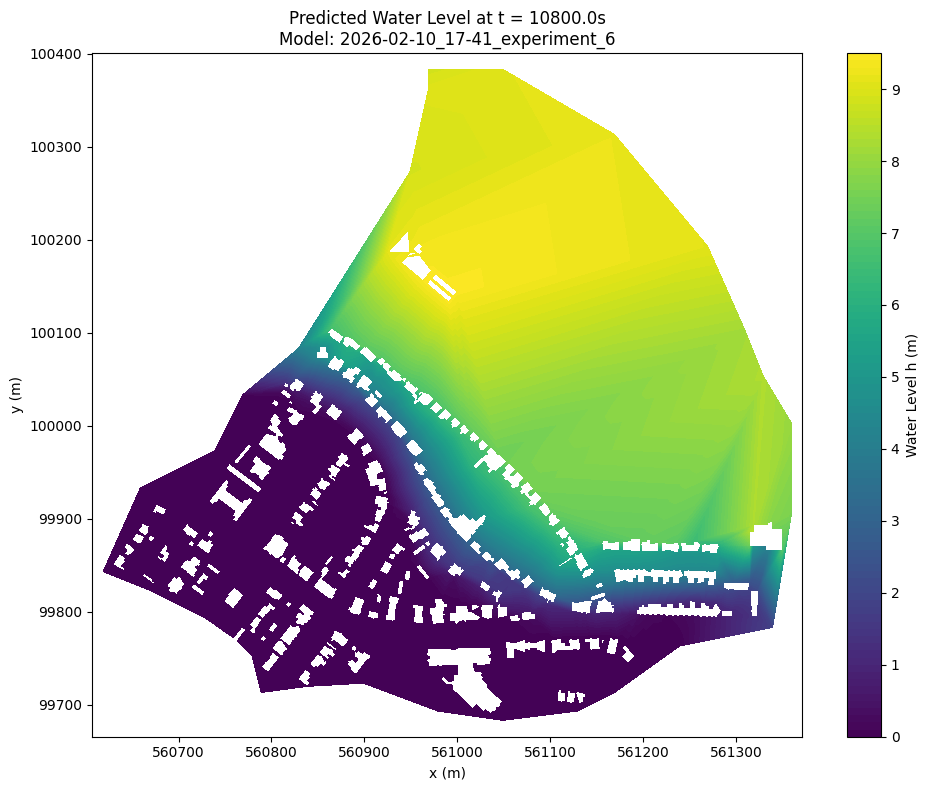

Visualization complete.


In [7]:
import sys
import os
import pickle
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from flax.core import FrozenDict

# --- 1. Setup Paths & Directories ---
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.config import load_config
from src.models import init_model
from src.data import IrregularDomainSampler

# --- 2. User Definitions ---
TRIAL_DIR_NAME = "2026-02-10_17-41_experiment_6" 
CONFIG_NAME = "experiment_6.yaml"
PLOT_TIMESTEPS = [0.0, 3600.0, 21600.0, 10800.0] 

# --- 3. Load Configuration FIRST ---
# We load config first to know which scenario (data folder) to use
config_path = os.path.join(project_root, "configs", CONFIG_NAME)
if not os.path.exists(config_path):
    raise FileNotFoundError(f"Config file not found: {config_path}")

cfg_dict = load_config(config_path)

# --- 4. Construct Data Paths Correctly ---
# Use the scenario name from config to find the data folder
scenario_name = cfg_dict.get('scenario', 'experiment_6')
base_data_path = os.path.join(project_root, "data", scenario_name)

# Check for artifacts
artifacts_path = os.path.join(base_data_path, "domain_artifacts.npz")
if not os.path.exists(artifacts_path):
    artifacts_path = os.path.join(base_data_path, "domain.npz")
    
if not os.path.exists(artifacts_path):
    raise FileNotFoundError(f"Domain artifacts not found at: {artifacts_path}")

print(f"Project Root: {project_root}")
print(f"Data Path: {base_data_path}")
print(f"Artifacts Path: {artifacts_path}")

# --- 5. Initialize Domain & Update Config ---
print(f"Loading domain geometry...")
domain_sampler = IrregularDomainSampler(artifacts_path)

# Calculate Domain Extent from the loaded sampler
all_coords = domain_sampler.tri_coords.reshape(-1, 2)
min_vals = jnp.min(all_coords, axis=0)
max_vals = jnp.max(all_coords, axis=0)

x_min, y_min = float(min_vals[0]), float(min_vals[1])
x_max, y_max = float(max_vals[0]), float(max_vals[1])

if 'domain' not in cfg_dict: cfg_dict['domain'] = {}
cfg_dict['domain'].update({
    'lx': x_max - x_min,
    'ly': y_max - y_min,
    'x_min': x_min, 'x_max': x_max,
    'y_min': y_min, 'y_max': y_max
})

# Freeze config for model init
cfg = FrozenDict(cfg_dict)

# --- 6. Initialize Model & Load Weights ---
model_dir = os.path.join(project_root, "models", TRIAL_DIR_NAME)

# Check for common weight filenames
potential_weight_files = [
    "model_weights.pkl", 
    f"{TRIAL_DIR_NAME}_params.pkl",
    "params.pkl"
]
weights_path = None
for f_name in potential_weight_files:
    p = os.path.join(model_dir, f_name)
    if os.path.exists(p):
        weights_path = p
        break

if not weights_path:
    raise FileNotFoundError(f"Could not find weight file in {model_dir}. Checked: {potential_weight_files}")

print(f"Loading weights from: {weights_path}")

# Init Model Structure
key = jax.random.PRNGKey(0)
try:
    models_module = __import__("src.models", fromlist=[cfg["model"]["name"]])
    model_class = getattr(models_module, cfg["model"]["name"])
except ImportError:
    raise ImportError(f"Could not import model {cfg['model']['name']}")

model, _ = init_model(model_class, key, cfg)

# Load Parameters
with open(weights_path, 'rb') as f:
    params = pickle.load(f)

# --- 7. Plotting ---
flat_coords = domain_sampler.tri_coords.reshape(-1, 2)
x_flat = flat_coords[:, 0]
y_flat = flat_coords[:, 1]

num_triangles = domain_sampler.tri_coords.shape[0]
triangles_indices = np.arange(num_triangles * 3).reshape(num_triangles, 3)
triangulation = tri.Triangulation(x_flat, y_flat, triangles_indices)

for t_val in PLOT_TIMESTEPS:
    print(f"Generating plot for t = {t_val}s...")
    t_input = jnp.full_like(x_flat, t_val)
    inputs = jnp.stack([jnp.array(x_flat), jnp.array(y_flat), t_input], axis=-1)
    
    U_pred = model.apply(params, inputs, train=False)
    h_pred = np.array(U_pred[..., 0])
    
    plt.figure(figsize=(10, 8))
    contour = plt.tricontourf(triangulation, h_pred, levels=100, cmap='viridis')
    plt.colorbar(contour, label='Water Level h (m)')
    plt.title(f"Predicted Water Level at t = {t_val}s\nModel: {TRIAL_DIR_NAME}")
    plt.xlabel('x (m)')
    plt.ylabel('y (m)')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

print("Visualization complete.")

Loading domain info from: /workspaces/swe-pinn/data/experiment_6/domain_artifacts.npz
Loading sampler artifacts from: /workspaces/swe-pinn/data/experiment_6/domain_artifacts.npz
  - Registered boundary 'wall': 21 segments
  - Registered boundary 'upstream': 5 segments
  - Registered boundary 'building': 3252 segments
Domain: X[560619.00, 561359.00], Y[99683.00, 100383.00]
Dimensions: lx=740.00, ly=700.00
Model weights loaded from /workspaces/swe-pinn/models/2026-02-10_17-41_experiment_6/2026-02-10_17-41_experiment_6_params.pkl

Processing Time: 14400.0s
Loading Mesh from: /workspaces/swe-pinn/data/experiment_6/2D Zones.shp
Calculating mesh centroids...
Inferencing on 5004 elements...


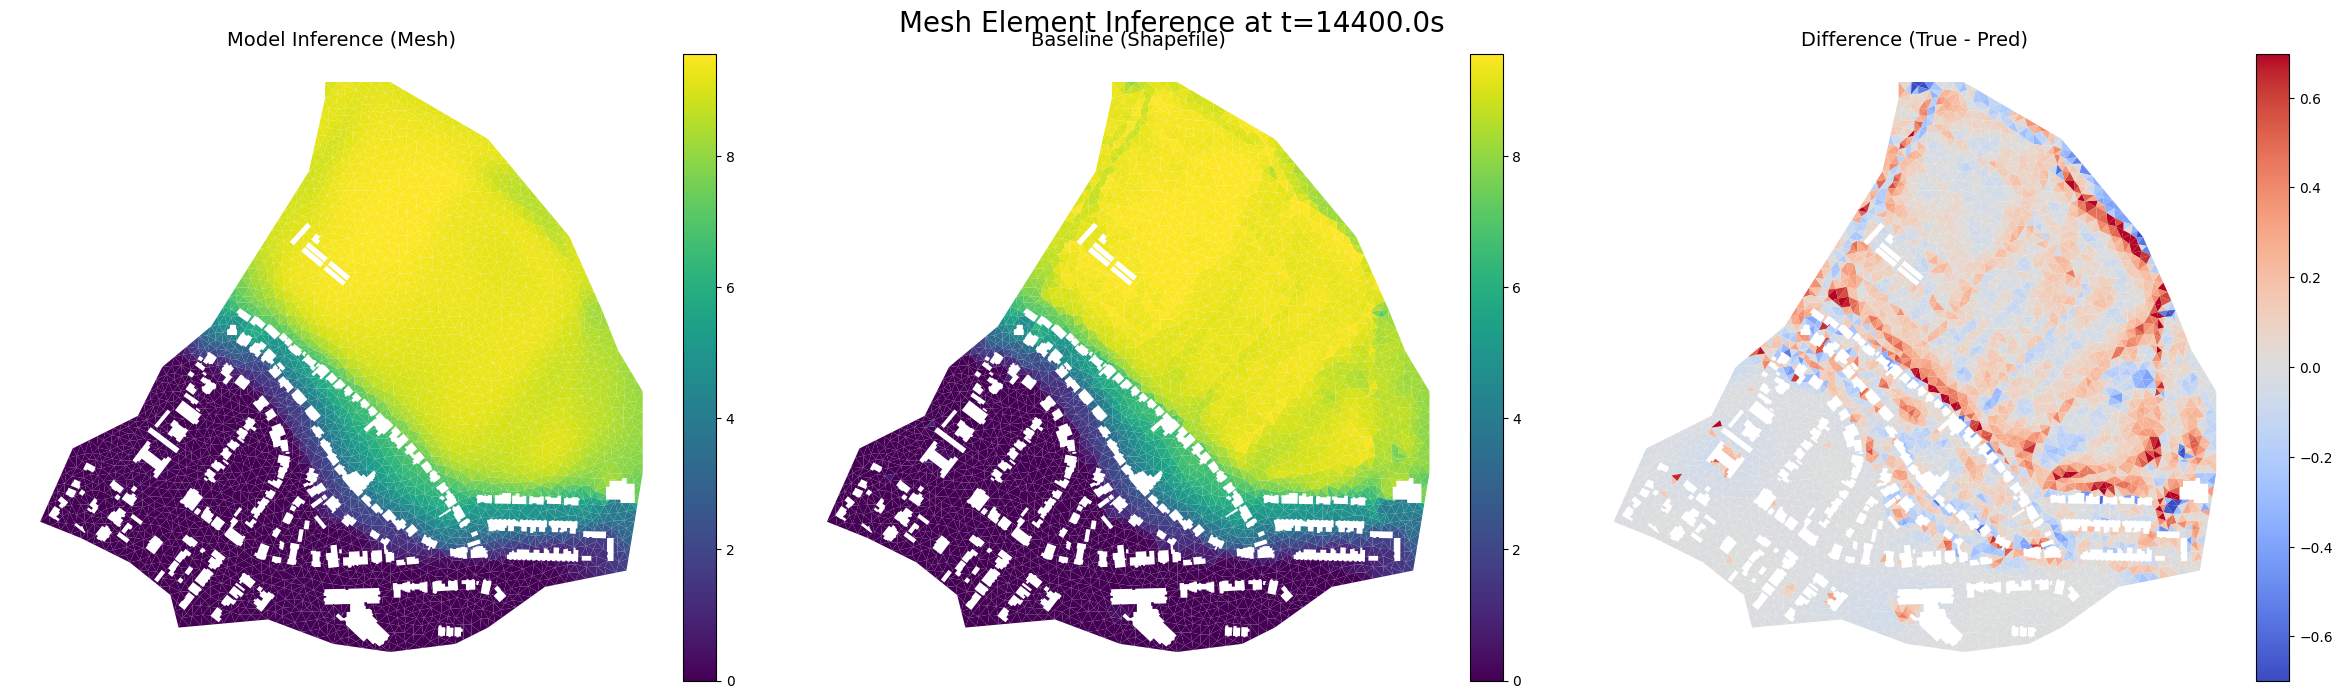

Mesh Visualization Complete.


In [5]:
import sys
import os
import pickle
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from flax.core import FrozenDict
import geopandas as gpd
from mpl_toolkits.axes_grid1 import make_axes_locatable

# --- 1. Setup Paths & Directories ---
# Adjust project root to point to the correct location relative to this script
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

# Import local modules
try:
    from src.config import load_config
    from src.models import init_model
    from src.data import IrregularDomainSampler
except ImportError as e:
    print(f"Error importing src modules: {e}")
    print(f"Current sys.path: {sys.path}")
    sys.exit(1)

# --- 2. User Definitions ---
TRIAL_DIR_NAME = "2026-02-10_17-41_experiment_6" 
CONFIG_NAME = "experiment_6.yaml"
TARGET_TIMES = [14400.0]

# Path to the directory containing your shapefiles
SHAPEFILE_DIR = os.path.join(project_root, "data", "experiment_6")

# --- 3. Load Configuration & Domain (Matches experiment_6.py logic) ---
config_path = os.path.join(project_root, "configs", CONFIG_NAME)
if not os.path.exists(config_path):
    # Fallback to look in the project root if running from a different location
    config_path = os.path.join(project_root, CONFIG_NAME)
    if not os.path.exists(config_path):
        raise FileNotFoundError(f"Config file not found: {config_path}")

cfg_dict = load_config(config_path)
scenario_name = cfg_dict.get('scenario', 'experiment_6')
base_data_path = os.path.join(project_root, "data", scenario_name)

# Load Artifacts to get exact Domain Extents (Crucial for Normalization)
artifacts_path = os.path.join(base_data_path, "domain_artifacts.npz")
if not os.path.exists(artifacts_path):
    artifacts_path = os.path.join(base_data_path, "domain.npz")

print(f"Loading domain info from: {artifacts_path}")
domain_sampler = IrregularDomainSampler(artifacts_path)

# Calculate domain extent exactly as done in experiment_6.py
all_coords = domain_sampler.tri_coords.reshape(-1, 2)
min_vals = np.min(all_coords, axis=0)
max_vals = np.max(all_coords, axis=0)

x_min, y_min = float(min_vals[0]), float(min_vals[1])
x_max, y_max = float(max_vals[0]), float(max_vals[1])
calc_lx = x_max - x_min
calc_ly = y_max - y_min

print(f"Domain: X[{x_min:.2f}, {x_max:.2f}], Y[{y_min:.2f}, {y_max:.2f}]")
print(f"Dimensions: lx={calc_lx:.2f}, ly={calc_ly:.2f}")

# Update Config
if 'domain' not in cfg_dict: cfg_dict['domain'] = {}
cfg_dict['domain'].update({
    'lx': calc_lx, 'ly': calc_ly,
    'x_min': x_min, 'x_max': x_max,
    'y_min': y_min, 'y_max': y_max
})
cfg = FrozenDict(cfg_dict)

# --- 4. Initialize Model & Load Weights ---
key = jax.random.PRNGKey(0)
try:
    models_module = __import__("src.models", fromlist=[cfg["model"]["name"]])
    model_class = getattr(models_module, cfg["model"]["name"])
except ImportError:
    raise ImportError(f"Could not import model {cfg['model']['name']}")

model, _ = init_model(model_class, key, cfg)

model_dir = os.path.join(project_root, "models", TRIAL_DIR_NAME)
# Try multiple common weight filenames
weight_candidates = ["model_weights.pkl", f"{TRIAL_DIR_NAME}_params.pkl", "params.pkl"]
weights_path = next((os.path.join(model_dir, f) for f in weight_candidates if os.path.exists(os.path.join(model_dir, f))), None)

if not weights_path:
    raise FileNotFoundError(f"Weights not found in {model_dir}")

with open(weights_path, 'rb') as f:
    params = pickle.load(f)
print(f"Model weights loaded from {weights_path}")

# --- 5. Processing & Mesh Plotting ---

def plot_mesh_comparison(gdf, time_t, h_pred_col, h_true_col):
    """
    Plots the mesh polygons colored by value.
    """
    h_pred = gdf[h_pred_col].values
    h_true = gdf[h_true_col].values
    
    # Calculate difference
    diff = h_true - h_pred
    gdf['difference_temp'] = diff

    # Determine scales for consistent visualization
    vmin = np.percentile(h_true, 2)
    vmax = np.percentile(h_true, 98)
    diff_abs = np.percentile(np.abs(diff), 99)

    fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    fig.suptitle(f"Mesh Element Inference at t={time_t}s", fontsize=20)

    # Helper for colorbars on geopandas plots
    def add_cbar(ax, label):
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1)
        return cax

    # 1. Prediction Plot
    ax = axes[0]
    gdf.plot(column=h_pred_col, ax=ax, legend=True, 
             cax=add_cbar(ax, "Water Depth (m)"),
             cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title("Model Inference (Mesh)", fontsize=14)
    ax.axis('off')

    # 2. Baseline Plot
    ax = axes[1]
    gdf.plot(column=h_true_col, ax=ax, legend=True, 
             cax=add_cbar(ax, "Water Depth (m)"),
             cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title("Baseline (Shapefile)", fontsize=14)
    ax.axis('off')

    # 3. Difference Plot
    ax = axes[2]
    gdf.plot(column='difference_temp', ax=ax, legend=True, 
             cax=add_cbar(ax, "Error (m)"),
             cmap='coolwarm', vmin=-diff_abs, vmax=diff_abs)
    ax.set_title("Difference (True - Pred)", fontsize=14)
    ax.axis('off')

    plt.tight_layout()
    plt.show()

# Main Loop over Target Times
for t_target in TARGET_TIMES:
    print(f"\nProcessing Time: {t_target}s")

    # --- A. Locate the Correct Shapefile ---
    # Logic: Look for "2D Zones.shp" directly, or a time-specific file like "2D Zones_3600.shp"
    # Given the user prompt "shapefile is in data/experiment_6/2D Zones.shp", we try that first.
    
    # 1. specific file attempt
    shp_name_time = f"2D Zones_{int(t_target)}.shp"
    shp_path_time = os.path.join(SHAPEFILE_DIR, shp_name_time)
    
    # 2. generic file attempt
    shp_path_generic = os.path.join(SHAPEFILE_DIR, "2D Zones.shp")

    if os.path.exists(shp_path_time):
        target_shp = shp_path_time
    elif os.path.exists(shp_path_generic):
        target_shp = shp_path_generic
    else:
        print(f"Warning: No shapefile found for t={t_target}. Checked {shp_path_time} and {shp_path_generic}")
        continue

    print(f"Loading Mesh from: {target_shp}")
    gdf = gpd.read_file(target_shp)

    # --- B. Verify Data Exists ---
    if 'DEPTH2D' not in gdf.columns:
        print(f"Error: 'DEPTH2D' column not found in {target_shp}. Skipping.")
        continue
    
    # If using a generic file for multiple timesteps, we assume the user might have
    # columns like 'DEPTH_3600'. If purely 'DEPTH2D', we assume the file IS the timestep data.
    # Proceeding with 'DEPTH2D' as the ground truth.

    # --- C. Prepare Model Input (Centroids) ---
    print("Calculating mesh centroids...")
    # We use centroids to approximate the value of the mesh element
    centroids = gdf.geometry.centroid
    x_vals = centroids.x.values
    y_vals = centroids.y.values
    t_vals = np.full_like(x_vals, t_target)
    
    print(f"Inferencing on {len(x_vals)} elements...")
    
    # Stack inputs: [x, y, t]
    inputs = jnp.stack([jnp.array(x_vals), jnp.array(y_vals), jnp.array(t_vals)], axis=-1)
    
    # --- D. Run Inference ---
    # The model returns [h, u, v] usually. We want index 0 for Depth.
    U_pred = model.apply(params, inputs, train=False)
    h_pred = np.array(U_pred[..., 0])
    
    # --- E. Assign Back to GeoDataFrame ---
    gdf['h_predicted'] = h_pred
    
    # --- F. Plotting ---
    plot_mesh_comparison(gdf, t_target, 'h_predicted', 'DEPTH2D')

print("Mesh Visualization Complete.")

In [ ]:
import sys
import os
import pickle
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from flax.core import FrozenDict
import geopandas as gpd
from mpl_toolkits.axes_grid1 import make_axes_locatable

# --- 1. Setup & Config ---
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.config import load_config
from src.models import init_model
from src.data import IrregularDomainSampler

# User Settings
TRIAL_DIR_NAME = "2026-02-10_17-41_experiment_6" 
CONFIG_NAME = "experiment_6.yaml"
# Update this path if your shapefile is named differently
SHAPEFILE_PATH = os.path.join(project_root, "data", "experiment_6", "2D Zones.shp")

# Animation Settings
T_START = 0.0
T_END = 21600.0   # 6 hours
DT_FRAME = 20.0   # Matches your validation_tensor.npy timestep
FRAME_DURATION = 30 # 0.3s per frame

# --- 2. Load Resources ---
config_path = os.path.join(project_root, "configs", CONFIG_NAME)
cfg_dict = load_config(config_path)

# Load Domain Artifacts (for Normalization)
scenario_name = cfg_dict.get('scenario', 'experiment_6')
base_data_path = os.path.join(project_root, "data", scenario_name)
artifacts_path = os.path.join(base_data_path, "domain_artifacts.npz")
if not os.path.exists(artifacts_path):
    artifacts_path = os.path.join(base_data_path, "domain.npz")

domain_sampler = IrregularDomainSampler(artifacts_path)
all_coords = domain_sampler.tri_coords.reshape(-1, 2)
x_min, y_min = np.min(all_coords, axis=0)
x_max, y_max = np.max(all_coords, axis=0)

cfg_dict['domain'] = {
    'lx': float(x_max - x_min), 'ly': float(y_max - y_min),
    'x_min': float(x_min), 'x_max': float(x_max),
    'y_min': float(y_min), 'y_max': float(y_max),
    't_final': T_END
}
cfg = FrozenDict(cfg_dict)

# --- 3. Initialize Model ---
key = jax.random.PRNGKey(0)
models_module = __import__("src.models", fromlist=[cfg["model"]["name"]])
model_class = getattr(models_module, cfg["model"]["name"])
model, _ = init_model(model_class, key, cfg)

# Load Weights
model_dir = os.path.join(project_root, "models", TRIAL_DIR_NAME)
weight_files = ["model_weights.pkl", f"{TRIAL_DIR_NAME}_params.pkl", "params.pkl"]
weights_path = next((os.path.join(model_dir, f) for f in weight_files if os.path.exists(os.path.join(model_dir, f))), None)

with open(weights_path, 'rb') as f:
    params = pickle.load(f)
print("Model weights loaded.")

# --- 4. Prepare Mesh Data ---
print(f"Loading Mesh: {SHAPEFILE_PATH}")
gdf = gpd.read_file(SHAPEFILE_PATH)

# Pre-calculate centroids (Static geometry)
# You mentioned these align with the validation_tensor x,y
centroids = gdf.geometry.centroid
x_vals = jnp.array(centroids.x.values)
y_vals = jnp.array(centroids.y.values)

# JIT-compile the inference step for speed
@jax.jit
def predict_at_t(params, x, y, t):
    t_arr = jnp.full_like(x, t)
    inputs = jnp.stack([x, y, t_arr], axis=-1)
    # Output index 0 is Depth (h)
    return model.apply(params, inputs, train=False)[..., 0] 

# --- 5. Setup Animation with Improved Colors ---
fig, ax = plt.subplots(figsize=(12, 10)) # Larger figure for better detail
div = make_axes_locatable(ax)
cax = div.append_axes("right", size="5%", pad=0.1)

# Initial Plot (t=0)
print("Initializing plot...")
h_init = predict_at_t(params, x_vals, y_vals, T_START)
gdf['h'] = np.array(h_init)

# --- COLOR & PLOT SETTINGS ---
# 'Blues' colormap: White -> Light Blue -> Dark Blue
# vmin=0.0: Ensures 0 depth is white (dry)
# vmax=3.0: Set this to the expected max flood depth (e.g., 3m or 5m)
vmin, vmax = 0.0, 3.0 

plot = gdf.plot(column='h', ax=ax, cmap='Blues', vmin=vmin, vmax=vmax, 
                legend=True, cax=cax, 
                edgecolor='face', # Hides polygon edges for smoother look
                linewidth=0.1)    # Thin lines if needed

ax.set_title(f"Simulation Time: {T_START:.1f} s", fontsize=16)
ax.axis('off')
ax.set_facecolor('white') 
cax.set_ylabel("Water Depth (m)", fontsize=12)

def update(frame_idx):
    current_t = T_START + frame_idx * DT_FRAME
    if current_t > T_END:
        return
    
    # 1. Inference
    h_pred = predict_at_t(params, x_vals, y_vals, current_t)
    
    # 2. Cleanup
    # Ensure no negative depths (numerical noise) for clean plotting
    h_clean = np.maximum(np.array(h_pred), 0.0)

    # 3. Update Plot
    # GeoPandas plot returns a PatchCollection. We update its scalar array.
    plot.collections[0].set_array(h_clean)
    
    ax.set_title(f"Simulation Time: {current_t:.1f} s", fontsize=16)
    
    if frame_idx % 10 == 0:
        print(f"Rendering frame {frame_idx} (t={current_t:.1f}s)...", end='\r')
    return plot.collections

# Calculate total frames
total_frames = int((T_END - T_START) / DT_FRAME) + 1

print(f"Starting Animation: {total_frames} frames, {DT_FRAME}s step.")

ani = animation.FuncAnimation(
    fig, 
    update, 
    frames=total_frames, 
    interval=FRAME_DURATION, # ms
    blit=False 
)

# --- 6. Save Video ---
output_file = os.path.join(project_root, "results", TRIAL_DIR_NAME, "mesh_inference_blues.mp4")
os.makedirs(os.path.dirname(output_file), exist_ok=True)

try:
    print(f"Saving to {output_file}...")
    # Use ffmpeg for MP4
    ani.save(output_file, writer='ffmpeg', fps=1000/FRAME_DURATION)
    print("Video saved successfully!")
except Exception as e:
    print(f"FFmpeg failed ({e}). Saving as GIF instead...")
    gif_file = output_file.replace(".mp4", ".gif")
    ani.save(gif_file, writer='pillow', fps=1000/FRAME_DURATION)
    print(f"GIF saved to {gif_file}")

plt.close()

--- Starting High-Quality Render Job ---
Loading Model...


FileNotFoundError: Config file not found at: /workspaces/swe-pinn/notebook/configs/experiment_6.yaml